#Consigna 3

#3.1 Configuración del entorno y carga de datos

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Configuración global de visualización (consistencia entre gráficos)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42  # semilla fija para reproducibilidad

In [2]:
# Carga del dataset
df = pd.read_csv('house-prices-tp.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 556 filas x 14 columnas


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


#3.2 Inspección del dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [4]:
col_numericas = df.select_dtypes(include=[np.number]).columns.to_list()
col_numericas.remove("MEDV") # Se elimina la variable target de la lista
target = "MEDV"
col_categorica = "CHAS"
if col_categorica in col_numericas:
    col_numericas.remove(col_categorica)

print(f"Variable categórica (dummy): {(col_categorica)}")
print(f"Variables numéricas: {col_numericas}, Cantidad:{len(col_numericas)}")
print("Variable target: MEDV")

Variable categórica (dummy): CHAS
Variables numéricas: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'], Cantidad:12
Variable target: MEDV


#3.3 Análisis descriptivo

In [5]:
descripcion = df.describe().T
# .T transpone la tabla para ver una variable por fila con sus estadísticas descriptivas.

descripcion["Sesgo"] = df[col_numericas + ["MEDV"]].skew()
# Indica qué tan asimétrica es la distribución de cada variable.
# Sesgo cercano a 0: aproximadamente simétrica.
# Sesgo > 0: cola hacia la derecha.
# Sesgo < 0: cola hacia la izquierda.

descripcion["Curtosis"] = df[col_numericas + ["MEDV"]].kurtosis()
# Indica qué tan pesadas son las colas de la distribución respecto a una normal.
# Curtosis cercana a 0: mesocúrtica.
# Curtosis > 0: leptocúrtica, con colas más pesadas.
# Curtosis < 0: platicúrtica, con colas más livianas y distribución más achatada.

descripcion

,count,mean,std,min,25%,50%,75%,max,Sesgo,Curtosis
CRIM,533.0,5.845517,13.828631,0.00632,0.08447,0.315330,4.871410,88.9762,3.746677,15.248736
ZN,534.0,13.197175,24.902981,0.00000,0.00000,0.000000,20.000000,100.0000,1.957797,2.749832
INDUS,541.0,11.218725,6.942021,0.46000,5.13000,9.690000,18.100000,27.7400,0.301523,-1.206425
CHAS,533.0,0.090056,0.286531,0.00000,0.00000,0.000000,0.000000,1.0000,NaN,NaN
NOX,532.0,0.560050,0.119472,0.38500,0.45300,0.538000,0.643986,0.8710,0.694358,-0.229572
RM,535.0,6.291839,0.782403,3.56100,5.87550,6.208000,6.638500,8.7800,0.373812,1.555062
AGE,532.0,67.632303,28.461925,2.90000,42.27500,76.500000,93.825000,100.0000,-0.550692,-1.038192
DIS,541.0,3.944102,2.255689,1.12960,2.11210,3.340107,5.400700,12.1265,1.078906,0.705364
RAD,528.0,9.699379,8.684495,1.00000,4.00000,5.000000,23.632660,24.0000,0.951478,-0.947840
TAX,538.0,409.575089,167.689379,187.00000,279.00000,335.000000,666.000000,711.0000,0.632306,-1.170504


##Criterio de interpretación
Para clasificar el sesgo y la curtosis se toma como referencia el criterio utilizado en el material de análisis exploratorio provisto por la cátedra.
Para el sesgo, se considera aproximadamente simétrica una distribución cuando (|sesgo| < 0.5\); moderadamente asimétrica cuando \(0.5 \le |sesgo| < 1\); y altamente asimétrica cuando (|sesgo| \ge 1\). Para la curtosis, se considera mesocúrtica cuando \(|curtosis| < 0.5\); leptocúrtica cuando la curtosis es positiva y supera dicho umbral; y platicúrtica cuando es negativa y su magnitud supera 0.5.

Luego de realizar una descripción sobre cada variable mediante estadísticas descriptivas, procedemos a analizar de cada una de las variables involucradas detallando características, comportamiento y rango de variación de las mismas.

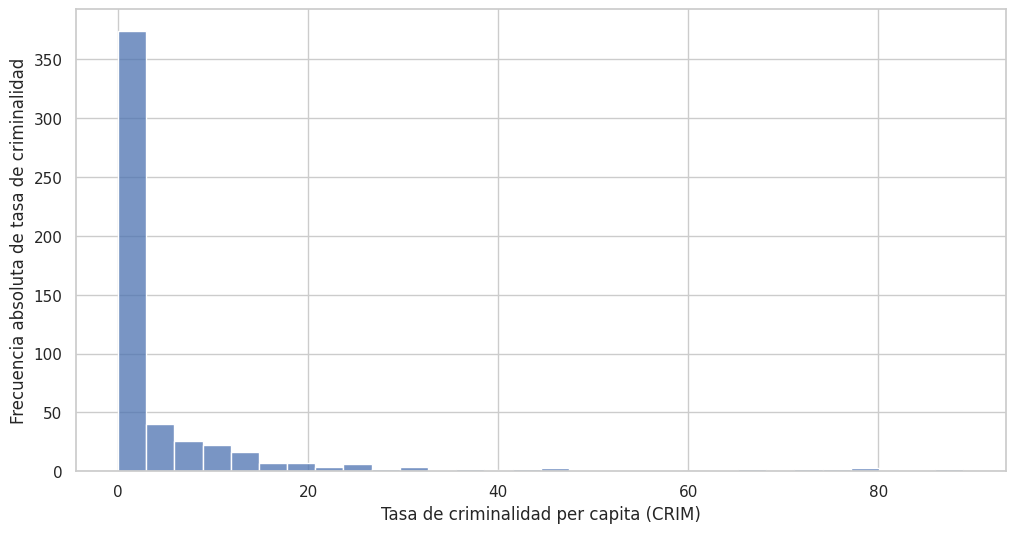

In [6]:
sns.histplot(df["CRIM"], bins = 30)
plt.ylabel("Frecuencia absoluta de tasa de criminalidad")
plt.xlabel("Tasa de criminalidad per capita (CRIM)");

La variable CRIM (tasa de criminalidad per cápita por ciudad) presenta valores entre 0.006320 y 88.976200, mostrando una variación alta en los datos. Con una media de aproximadamente 5.845 y una mediana de aproximadamente     0.315, lo que nos está indicando que la mayoría de las observaciones se concentra en valores bajos. Además, presenta un sesgo positivo alto con un valor aproximado de 3.746, lo que nos está indicando distribución asimétrica positiva con cola hacia la derecha. A su vez, posee una curtosis también elevada con un valor aproximado de 15.248, lo que indica una distribución leptocúrtica con colas más pesadas.

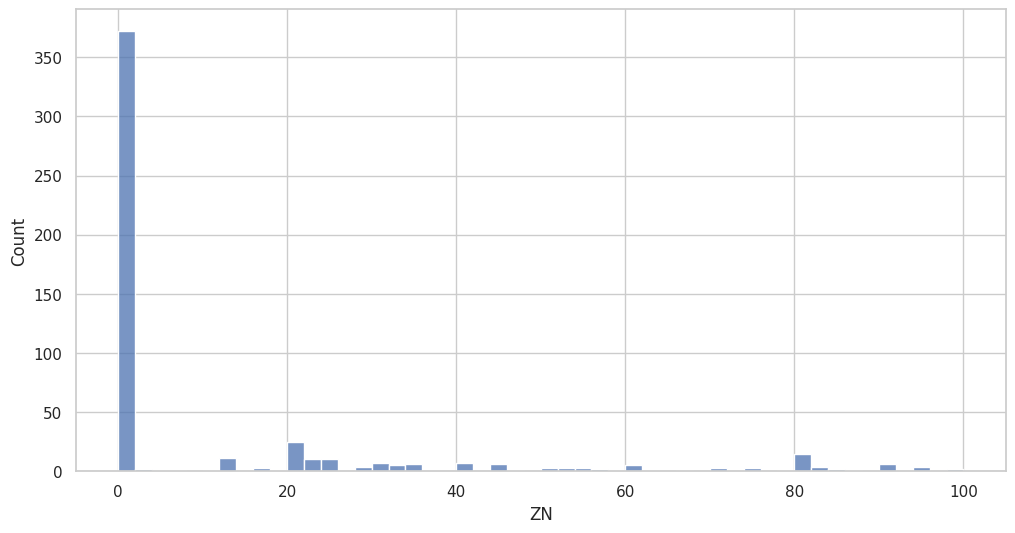

In [7]:
sns.histplot(df["ZN"], bins = 50);

La variable ZN (proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies cuadrados) presenta valores entre 0 y 100, indicando una variación alta dentro de la proporción. En el gráfico realizado se puede observar que los valores de la proporción tienen una alta concentración en 0, siendo que Q1 y la mediana(Q2) presentan valores de 0. La media es de aproximadamente 13.197 y una desviación estándar aproximada de 24.902, indicando una dispersión considerable de los datos. La variable presenta un sesgo positivo alto con un valor aproximado de 1.957 indicando que tiene una distribución asimétrica con cola hacia la derecha. A su vez también presenta una curtosis elevada con un valor aproximado de 2.749, indicando presencia de colas pesadas

In [8]:
df["ZN"].value_counts().sort_index().head()
# De esta manera podemos visualizar mas a detalle no solamente con el grafico la cantidad de valores existentes en la variable ZN

,count
ZN,
0.000000,372
2.897541,1
3.495754,1
5.985746,1
6.528591,1


La variable INDUS (proporción de acres de negocios no minoristas por ciudad) presenta valores entre 0.46 y 27.74, con una media aproximada de 11.22 y una mediana de 9.69. La desviación estándar es de aproximadamente 6.94, mostrando una dispersión moderada de los datos. Presenta un sesgo de aproximadamente 0.30, por lo que puede considerarse aproximadamente simétrica. A su vez, su curtosis es de aproximadamente -1.21, indicando una distribución platicúrtica, más achatada y con colas más livianas respecto de una distribución normal.

La variable CHAS (variable dummy del río Charles (1 si el tramo limita con el río; 0 de lo contrario)) es una variable dummy que explica si el tramo limita con el río Charles o no. Habiendo realizado un calculo, podemos observar que aproximadamente el 87.23% de los datos obtenidos no limitan con el río, en cambio aproximadamente un 8.6% si limita con el río y un aproximado de 4.13% de valores faltantes

In [9]:
df["CHAS"].value_counts(normalize=True, dropna=False).mul(100)

,proportion
CHAS,
0.0,87.230216
1.0,8.633094
NaN,4.136691


La variable NOX tiene valores entre 0.385 y 0.871, con una media aproximada de 0.56 y un desvío estándar de 0.119. Presenta un sesgo positivo aproximado de 0.69, por lo que tiene una asimetría moderada hacia la derecha. Además, su curtosis es aproximadamente -0.22, por lo que puede considerarse una distribución aproximadamente mesocúrtica.

La variable RM (número promedio de habitaciones por vivienda) posee un rango entre 3.56100 y 8.78. Junto a esto, tiene una media aproximada de 6.29 y una desviacion estandar aproximada de 0.78, lo que indica una baja variación entre los datos con respecto a su escala. A su vez, posee un sesgo aproximado de 0.37, indicando una distribución aproximadamente simétrica y una curtosis aproximada de 1.55, indicando una distribución leptocúrtica con colas pesadas.

La variable AGE tiene valores entre 2.9 y 100, por lo que presenta una variación bastante amplia. Su media es aproximadamente 67.63 y su desvío estándar es de 28.46, lo que muestra que los datos están bastante dispersos. Además, tiene un sesgo aproximado de -0.55, por lo que presenta una asimetría moderada hacia la izquierda.

<Axes: xlabel='AGE', ylabel='Count'>

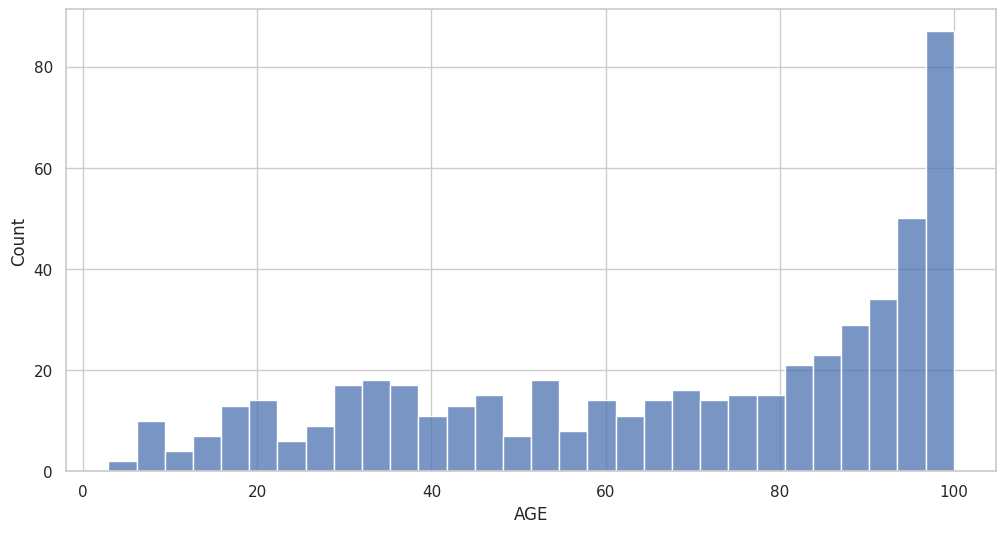

In [10]:
sns.histplot(df["AGE"], bins = 30)

La variable DIS (distancias ponderadas a cinco centros de empleo de Boston) posee un rango entre 1.1296 y 12.1265. Junto a esto, tiene una media aproximada de 3.94 y una desviación estándar aproximada de 2.25, indicando una dispersión considerable de los datos con respecto a su escala. A su vez, posee un sesgo positivo aproximado de 1.08, indicando una distribución asimétrica con cola hacia la derecha. También presenta una curtosis aproximada de 0.71, indicando una distribución leptocúrtica con colas algo más pesadas que una distribución normal.

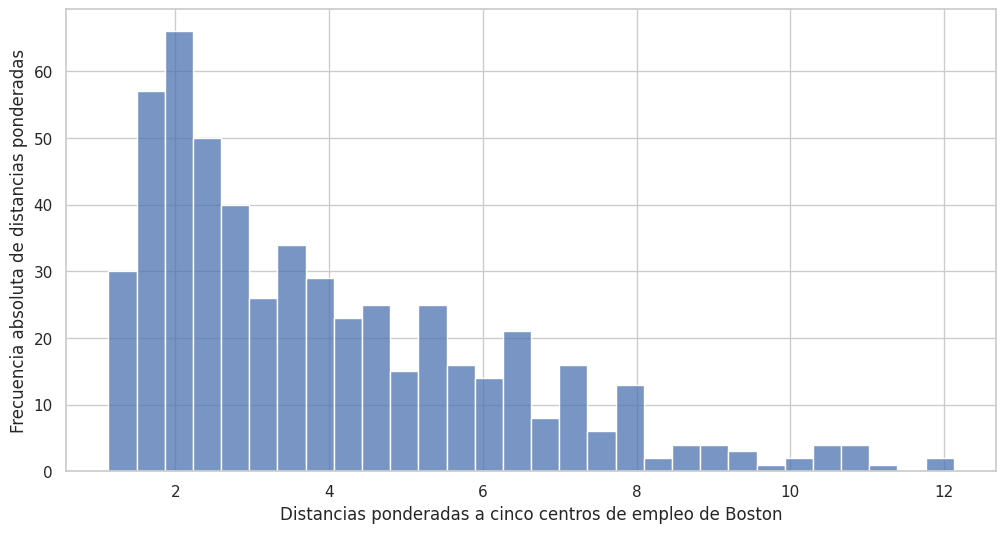

In [11]:
sns.histplot(df["DIS"], bins = 30);
plt.xlabel("Distancias ponderadas a cinco centros de empleo de Boston")
plt.ylabel("Frecuencia absoluta de distancias ponderadas");

La variable RAD (índice de accesibilidad a las autopistas radiales) posee un rango entre 1 y 24. Junto a esto, tiene una media aproximada de 9.70 y una desviación estándar aproximada de 8.68, indicando una dispersión considerable de los datos con respecto a su escala. A su vez, posee un sesgo positivo aproximado de 0.95, indicando una distribución asimétrica con cola hacia la derecha. También presenta una curtosis aproximada de -0.95, indicando una distribución platicúrtica, más achatada y con colas más livianas que una distribución normal.

La variable TAX (tasa de impuesto sobre la propiedad a valor completo por $10,000) posee un rango entre 187 y 711. Junto a esto, tiene una media aproximada de 409.58 y una desviación estándar aproximada de 167.69, indicando una dispersión considerable de los datos con respecto a su escala. A su vez, posee un sesgo positivo aproximado de 0.63, indicando una distribución asimétrica con cola hacia la derecha. También presenta una curtosis aproximada de -1.17, indicando una distribución platicúrtica, más achatada y con colas más livianas que una distribución normal.

La variable PTRATIO (proporción alumno-maestro por ciudad) posee un rango entre 12.6 y 22. Junto a esto, tiene una media aproximada de 18.43 y una desviación estándar aproximada de 2.19, indicando una variación relativamente baja de los datos con respecto a su escala. A su vez, posee un sesgo negativo aproximado de -0.79, indicando una distribución asimétrica con cola hacia la izquierda. También presenta una curtosis aproximada de -0.30, indicando una distribución levemente más achatada respecto de una normal.

La variable B posee un rango entre 0.32 y 396.9. Junto a esto, tiene una media aproximada de 347.81 y una desviación estándar aproximada de 99.64, indicando una dispersión considerable de los datos. A su vez, posee un sesgo negativo alto de aproximadamente -2.40, indicando una distribución fuertemente asimétrica con cola hacia la izquierda. También presenta una curtosis elevada de aproximadamente 4.50, indicando una distribución leptocúrtica con colas pesadas.

Text(0, 0.5, 'Frecuencia absoluta')

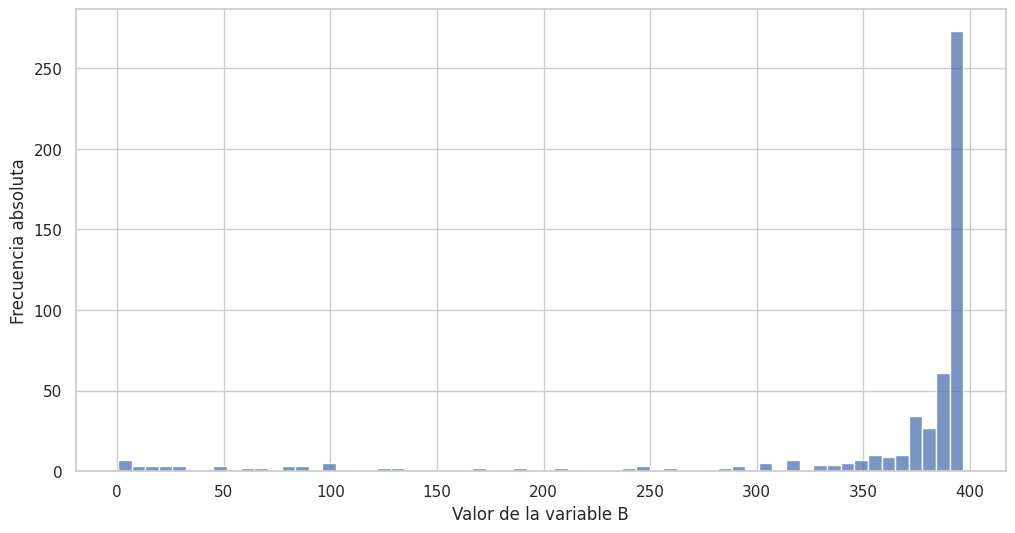

In [12]:
sns.histplot(df["B"]);
plt.xlabel("Valor de la variable B")
plt.ylabel("Frecuencia absoluta")

La variable LSTAT (% de población de menor estatus socioeconómico) posee un rango entre 1.73 y 37.97. Junto a esto, tiene una media aproximada de 13.03 y una desviación estándar aproximada de 7.58, indicando una dispersión considerable de los datos con respecto a su escala. A su vez, posee un sesgo positivo aproximado de 0.95, indicando una distribución asimétrica con cola hacia la derecha. También presenta una curtosis aproximada de 0.48, cercana a una distribución mesocúrtica.

La variable MEDV (valor mediano de las viviendas ocupadas por sus propietarios, en miles de dólares) posee un rango entre 5 y 50. Junto a esto, tiene una media aproximada de 22.75 y una desviación estándar aproximada de 9.49, indicando una dispersión considerable de los valores. A su vez, posee un sesgo positivo aproximado de 1.06, indicando una distribución asimétrica con cola hacia la derecha. También presenta una curtosis aproximada de 1.17, indicando una distribución leptocúrtica con colas pesadas.

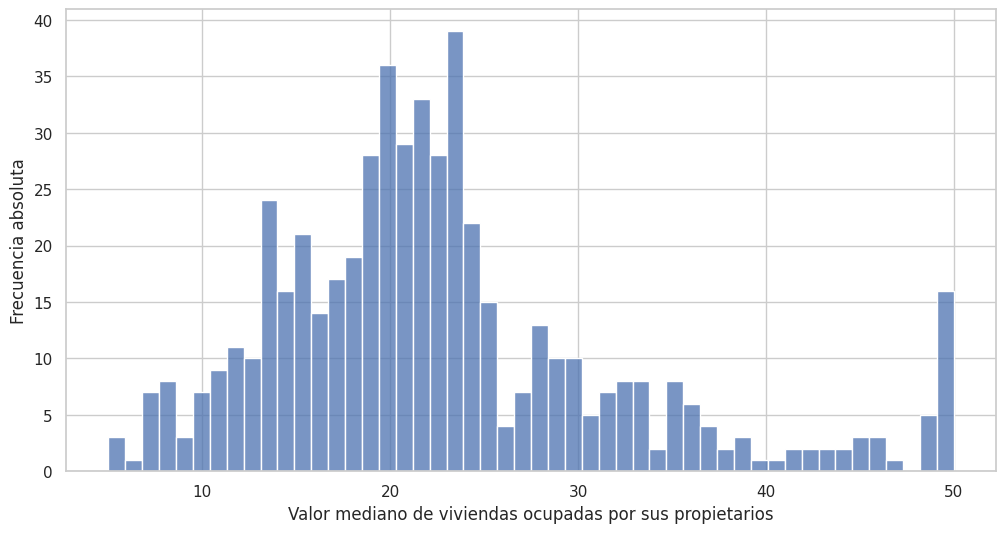

In [13]:
sns.histplot(df["MEDV"], bins = 50)
plt.xlabel("Valor mediano de viviendas ocupadas por sus propietarios")
plt.ylabel("Frecuencia absoluta");

Las variables CRIM, B, ZN, DIS y MEDV presentan sesgo marcado (|sesgo| > 1). CRIM y B son las más extremas:

In [14]:
descripcion


,count,mean,std,min,25%,50%,75%,max,Sesgo,Curtosis
CRIM,533.0,5.845517,13.828631,0.00632,0.08447,0.315330,4.871410,88.9762,3.746677,15.248736
ZN,534.0,13.197175,24.902981,0.00000,0.00000,0.000000,20.000000,100.0000,1.957797,2.749832
INDUS,541.0,11.218725,6.942021,0.46000,5.13000,9.690000,18.100000,27.7400,0.301523,-1.206425
CHAS,533.0,0.090056,0.286531,0.00000,0.00000,0.000000,0.000000,1.0000,NaN,NaN
NOX,532.0,0.560050,0.119472,0.38500,0.45300,0.538000,0.643986,0.8710,0.694358,-0.229572
RM,535.0,6.291839,0.782403,3.56100,5.87550,6.208000,6.638500,8.7800,0.373812,1.555062
AGE,532.0,67.632303,28.461925,2.90000,42.27500,76.500000,93.825000,100.0000,-0.550692,-1.038192
DIS,541.0,3.944102,2.255689,1.12960,2.11210,3.340107,5.400700,12.1265,1.078906,0.705364
RAD,528.0,9.699379,8.684495,1.00000,4.00000,5.000000,23.632660,24.0000,0.951478,-0.947840
TAX,538.0,409.575089,167.689379,187.00000,279.00000,335.000000,666.000000,711.0000,0.632306,-1.170504


#3.4 Análisis y decisión sobre datos faltantes

In [15]:
# Mostramos el porcentaje de nulos de cada variable respecto al total y la cantidad de faltantes en cada variable
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos.round(2)})
reporte_nulos = reporte_nulos[reporte_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
reporte_nulos

,Nulos,Porcentaje (%)
PTRATIO,28,5.04
RAD,28,5.04
NOX,24,4.32
AGE,24,4.32
CHAS,23,4.14
CRIM,23,4.14
LSTAT,22,3.96
B,22,3.96
ZN,22,3.96
RM,21,3.78


In [16]:
# Mostramos la cantidad de filas con su respectiva proporcion en faltantes
porcentaje_nulos_fila = df.isna().mean(axis=1) * 100
porcentaje_nulos_fila.value_counts().sort_index()

,count
0.000000,506
7.142857,5
14.285714,3
21.428571,11
28.571429,3
35.714286,3
42.857143,2
50.000000,5
57.142857,4
64.285714,4


Luego de revisar los valores faltantes respecto al total de los datos del dataset, consideramos eliminar las filas donde la variable target (MEDV) posee un valor faltante. Tomamos esta decisión porque imputar valores en la variable objetivo implicaría introducir datos artificiales justamente en la variable que el modelo debe aprender a predecir, lo que podría afectar el resultado del entrenamiento.

In [17]:
df = df.dropna(subset=["MEDV"])

In [18]:
# Recalculamos cantidad y porcentaje de nulos por variable luego de eliminar los faltantes en la variable MEDV
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos.round(2)})
reporte_nulos = reporte_nulos[reporte_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
reporte_nulos

,Nulos,Porcentaje (%)
RAD,12,2.24
ZN,11,2.06
CRIM,11,2.06
AGE,11,2.06
CHAS,9,1.68
B,9,1.68
NOX,9,1.68
PTRATIO,9,1.68
TAX,9,1.68
LSTAT,9,1.68


In [19]:
porcentaje_faltantes_fila = df.isna().mean(axis=1) * 100
porcentaje_faltantes_fila.value_counts().sort_index()

,count
0.000000,506
7.142857,5
14.285714,3
21.428571,9
28.571429,2
35.714286,2
42.857143,1
50.000000,4
57.142857,2
64.285714,1


In [20]:
# Eliminar filas con mas del 50% de columnas faltantes
pct_nulos_fila = df.isnull().sum(axis=1) / df.shape[1] * 100

print('Filas con mas del 50% de columnas faltantes:', (pct_nulos_fila > 50).sum())

df = df[pct_nulos_fila <= 50]

Filas con mas del 50% de columnas faltantes: 3


Elegimos un 50% para que garantice que la fila conserve más información real que faltante.

En total se eliminaron 24 filas de 556 (4.32%), por debajo del límite del 5% establecido para no generar un desvío estadístico en el dataset.

In [21]:
# Chequeo de filas duplicadas
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {n_duplicados} de {len(df)} ({n_duplicados/len(df)*100:.2f}%)')

Filas duplicadas: 0 de 532 (0.00%)


No se encontraron datos duplicados en el dataset, por lo que no fue necesaria ninguna decisión de eliminación en este aspecto.

### Análisis del mecanismo de datos faltantes

MCAR (Missing Completely At Random):los valores faltantes aparecen completamente al azar y no dependen de ninguna otra variable del dataset.

MAR (Missing At Random): los valores faltantes pueden depender de otras variables observadas del dataset, pero no del propio valor faltante.

MNAR (Missing Not At Random): los valores faltantes dependen del propio valor que falta o de alguna causa no observada.

En nuestro caso se observan diferencias entre algunas variables en filas con y sin datos faltantes, por lo que no parece adecuado asumir que los faltantes sean MCAR.

Conclusión:

Con este análisis exploratorio no es posible determinar con certeza si el mecanismo de faltantes es MAR o MNAR, por lo que no se realiza una afirmación definitiva al respecto.


#3.5 Visualización de datos y valores atipicos

###Distribución de las variables

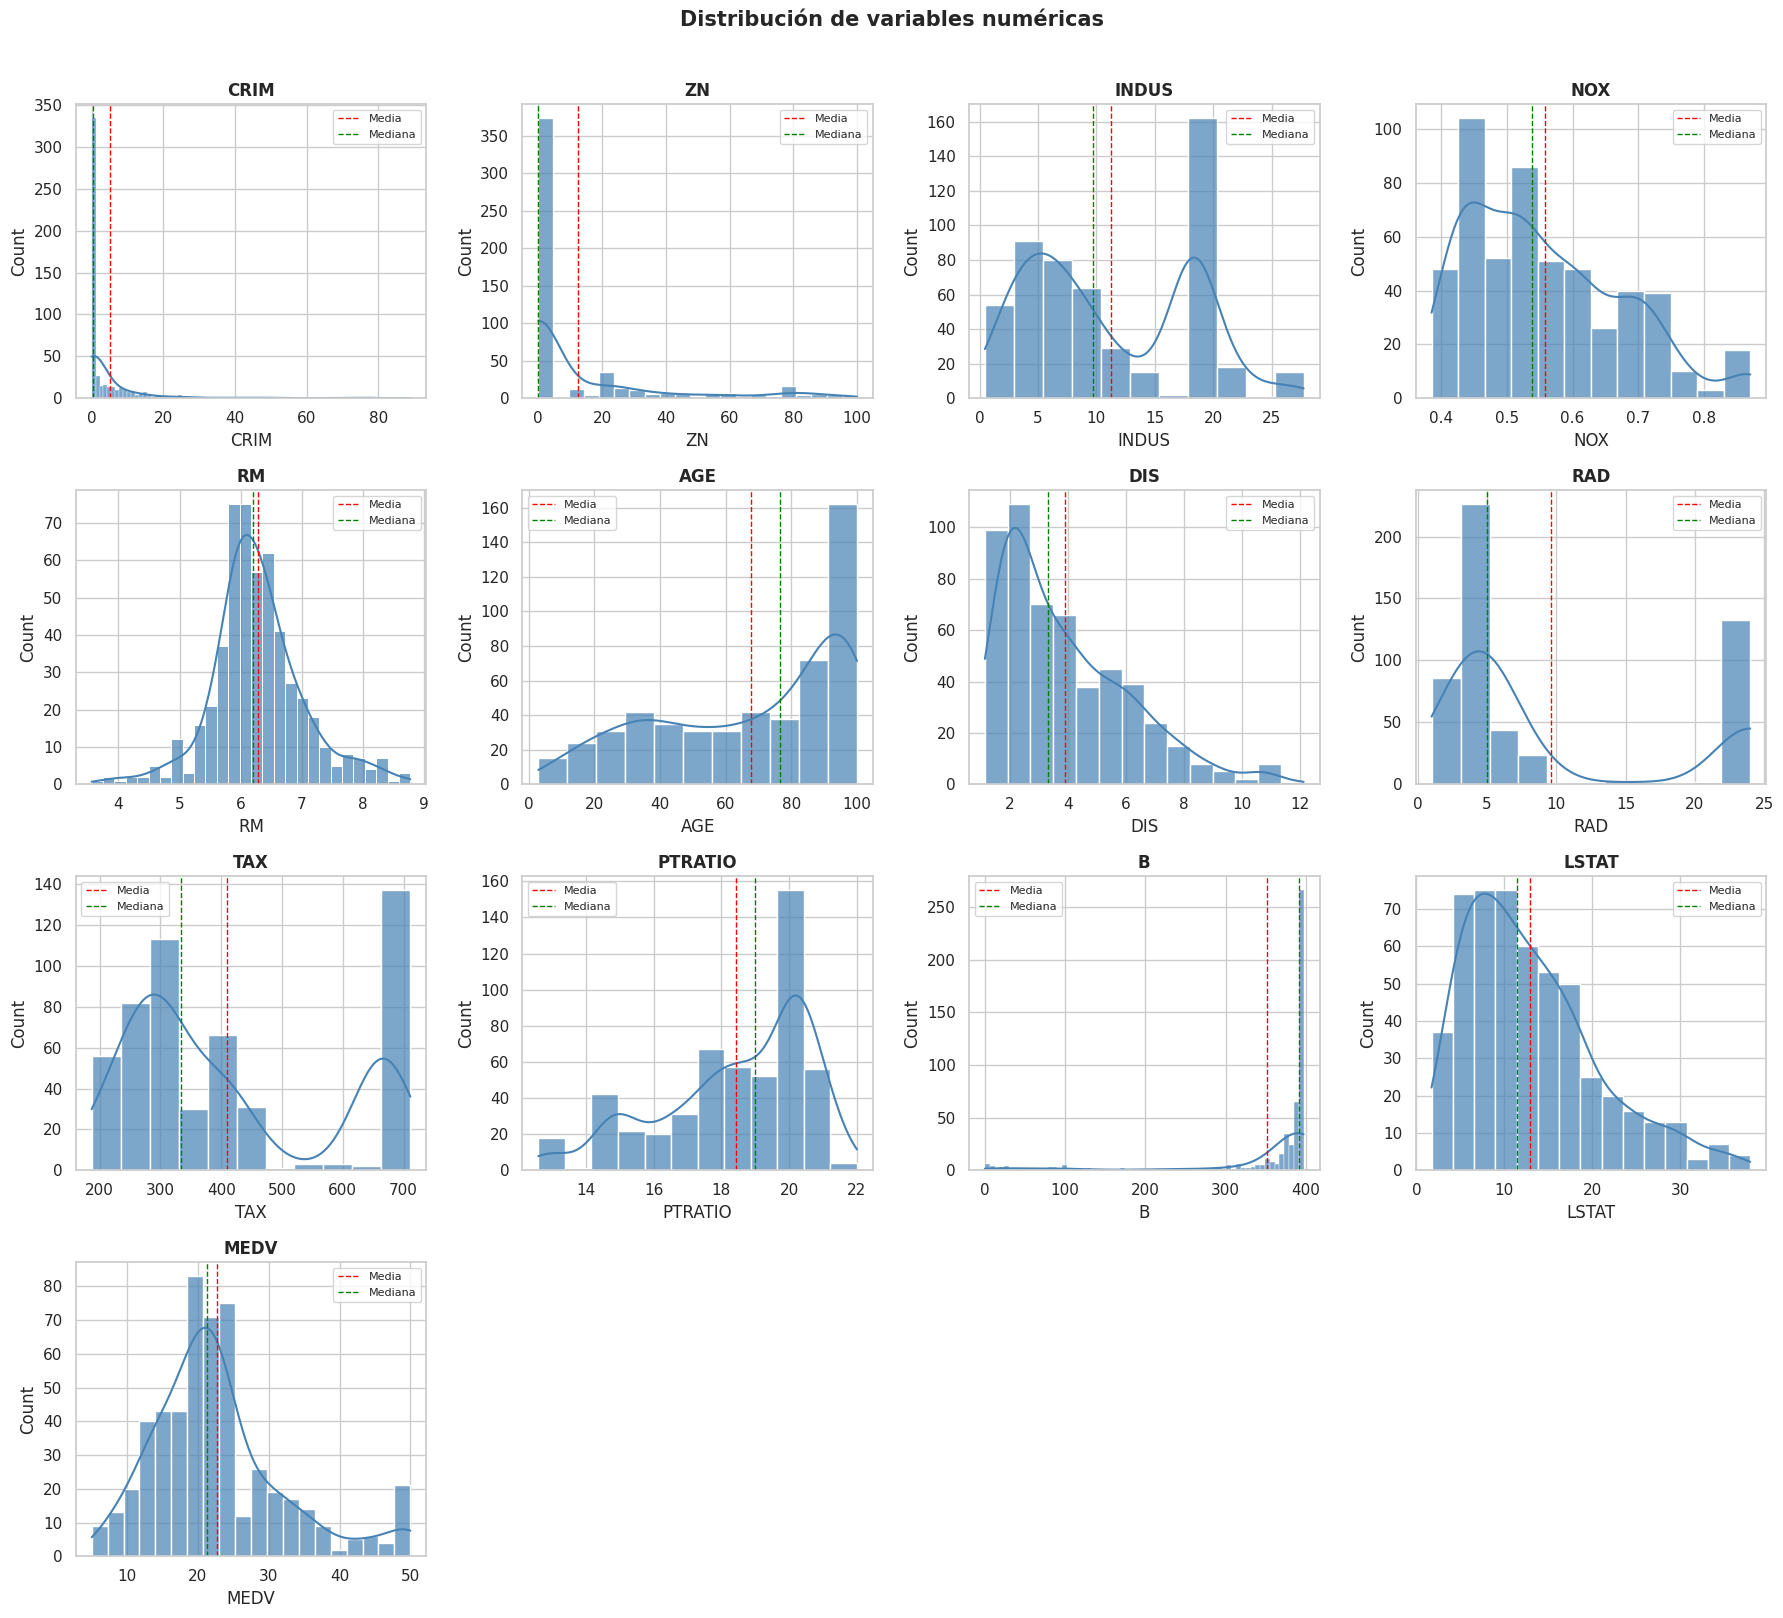

In [22]:
# Histogramas de todas las variables numéricas
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(col_numericas + ['MEDV']):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='Media')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=1, label='Mediana')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(len(col_numericas) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Los histogramas confirman visualmente:

Sesgo positivo: CRIM, ZN y DIS presentan una asimetría positiva clara, con mayor concentración de observaciones en valores bajos y una cola extendida hacia la derecha. En LSTAT también se observa asimetría positiva, aunque de forma moderada. Esto es coherente con los valores de sesgo calculados anteriormente.

Sesgo negativo: B y AGE presentan asimetría hacia la izquierda. En B, la mayoría de los valores se concentra cerca de los valores máximos, mientras que una menor cantidad de observaciones se extiende hacia valores bajos.

RAD y TAX: presentan dos concentraciones de valores claramente diferenciadas, lo que visualmente sugiere una posible distribución bimodal. En RAD se observa un grupo importante de valores bajos y otro concentrado cerca de 24, mientras que en TAX ocurre algo similar con una concentración adicional en valores elevados.

Distribución aproximadamente simétrica: RM es la variable que más se aproxima a una distribución simétrica, con una forma similar a una campana y valores de media y mediana cercanos entre sí.

MEDV (target): presenta una asimetría positiva y una concentración importante de valores alrededor de 20–25. Además, se observa una acumulación de observaciones en 50, lo que podría indicar la presencia de un límite superior en la variable.

### Detección de valores atípicos

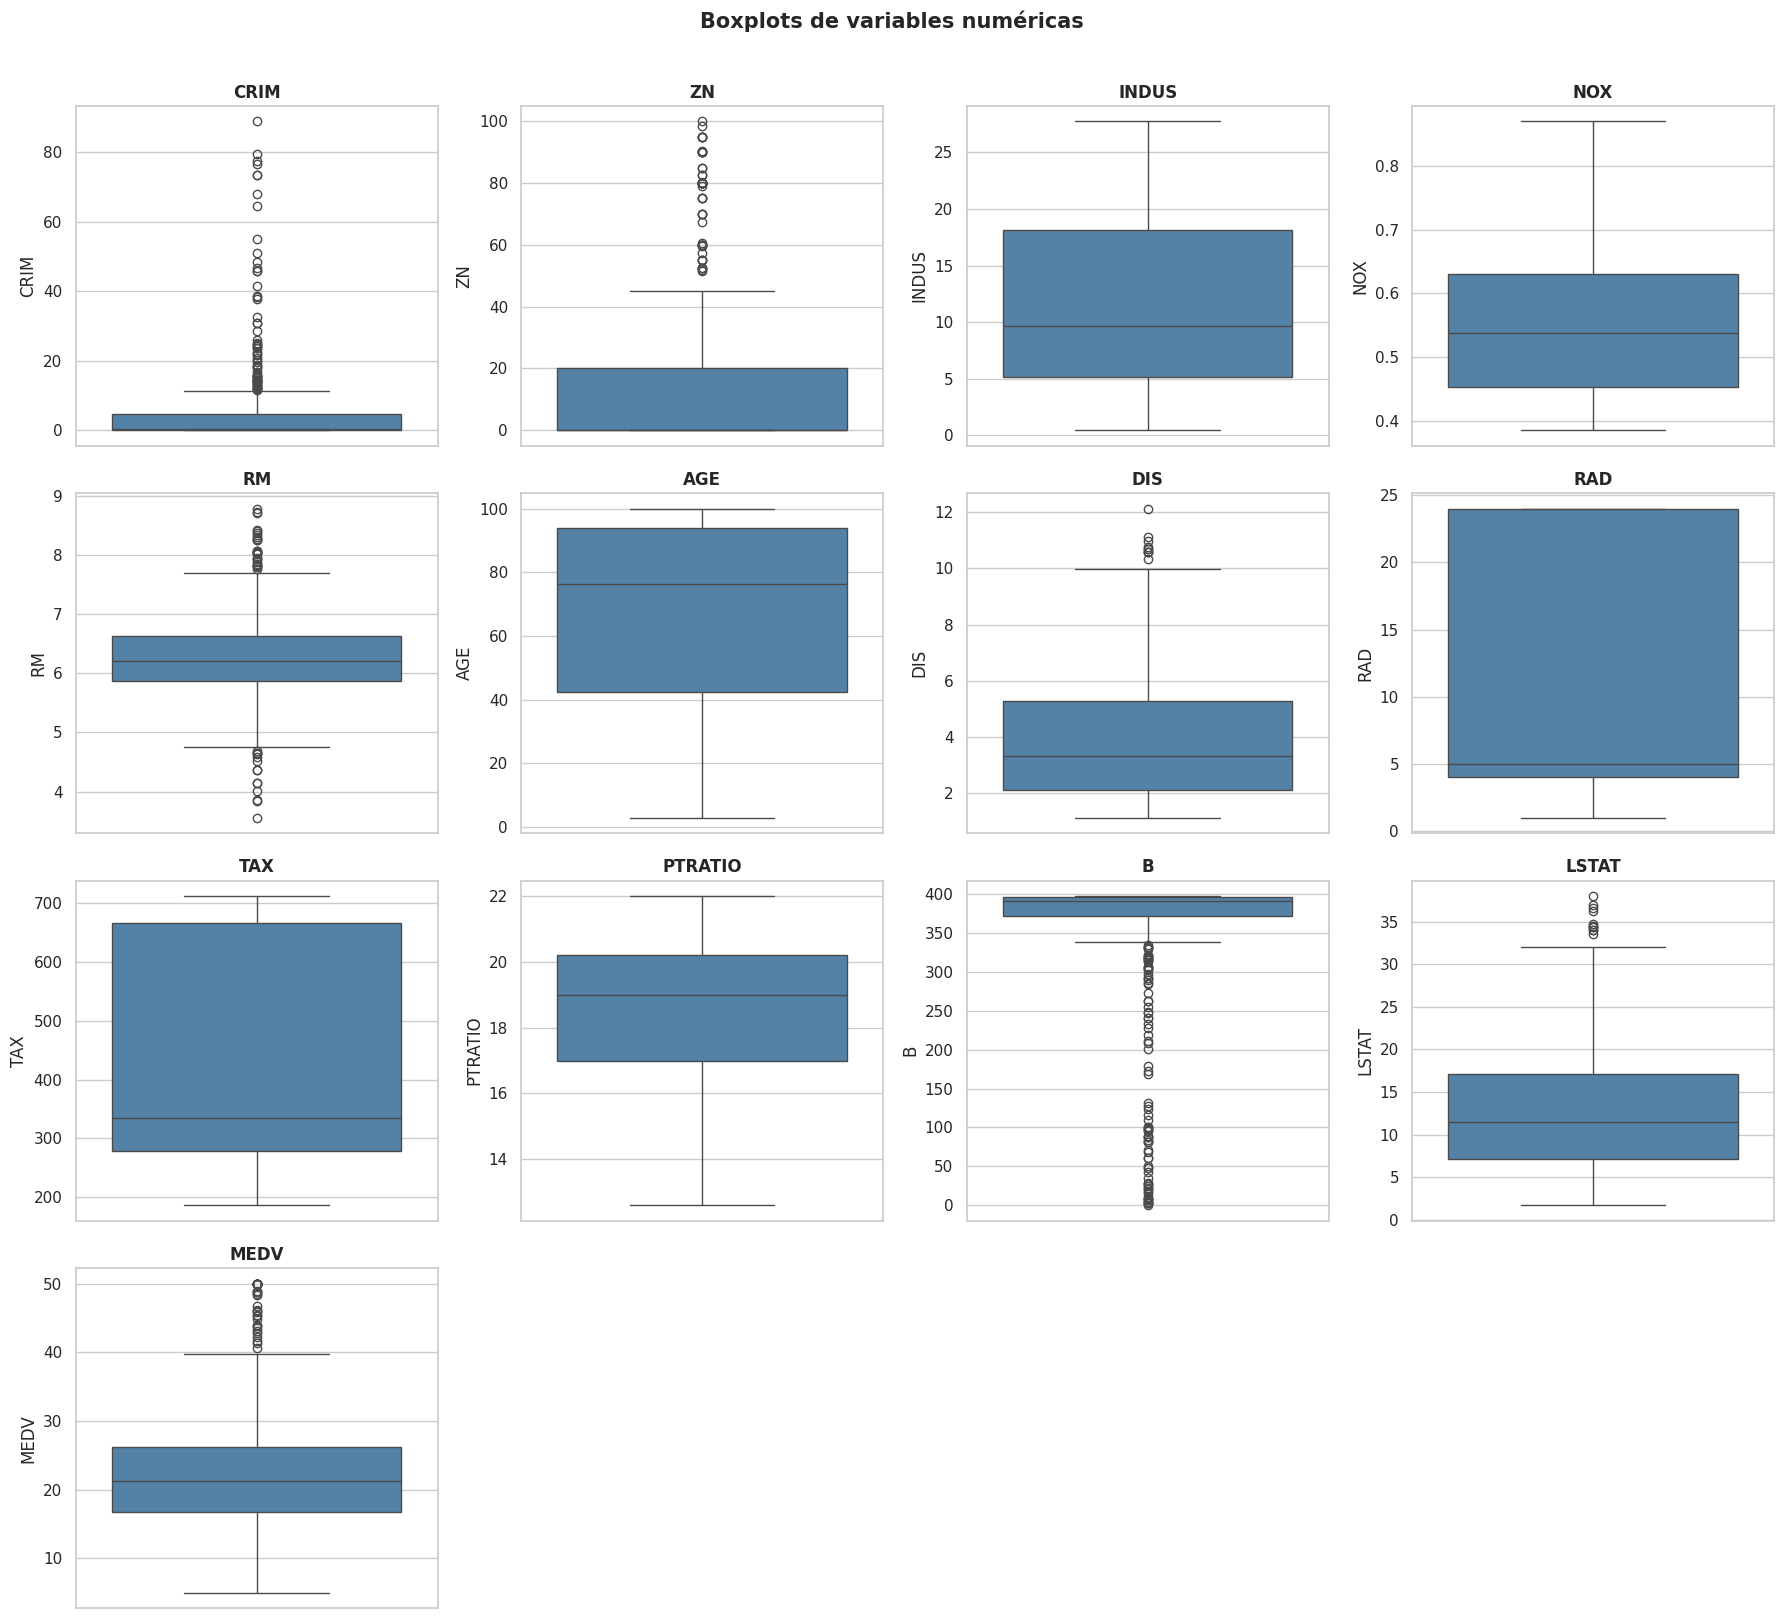

In [23]:
# Boxplots para deteccion de outliers
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(col_numericas + ['MEDV']):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontweight='bold')

for j in range(len(col_numericas) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de variables numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Se optó por no eliminar automáticamente los valores atípicos detectados mediante el criterio IQR, ya que no se encontraron indicios de que correspondan a errores de carga. En variables como CRIM y B, los valores extremos forman parte de la propia distribución de los datos y representan observaciones poco frecuentes pero posibles. Eliminarlos podría modificar considerablemente la distribución de estas variables y reducir la representatividad del dataset.

De manera similar, los valores atípicos observados en ZN, RM, LSTAT y DIS pueden interpretarse como variaciones reales entre zonas con diferentes características urbanas, por lo que también se decidió conservarlos.

El caso de MEDV presenta una particularidad: se observa una acumulación de observaciones en el valor máximo de 50. Este comportamiento sugiere la existencia de un límite superior en el registro de la variable. Aun así, estas observaciones se conservan, ya que eliminarlas implicaría perder información correspondiente a viviendas de alto valor.

## Codificación de la variable categórica

La variable CHAS es una variable dummy que ya se encuentra codificada numéricamente con los valores 0 y 1, por lo que no es necesario aplicar una transformación adicional como One-Hot Encoding o Label Encoding.

Sin embargo, presenta valores faltantes, por lo que será necesario definir una estrategia de imputación antes de utilizarla en los modelos.


##3.6 Matriz de correlación

In [24]:
corr = df.corr(method='pearson')
corr.round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,0.01,0.34,0.15,0.37,-0.17,0.22,-0.18,0.53,0.48,0.25,-0.40,0.43,-0.23
ZN,0.01,1.00,-0.47,0.02,-0.45,0.26,-0.57,0.65,-0.29,-0.29,-0.35,0.12,-0.34,0.36
INDUS,0.34,-0.47,1.00,0.10,0.73,-0.36,0.60,-0.63,0.58,0.70,0.37,-0.32,0.54,-0.42
CHAS,0.15,0.02,0.10,1.00,0.12,-0.01,0.03,-0.04,0.01,-0.04,-0.11,-0.05,-0.00,0.21
NOX,0.37,-0.45,0.73,0.12,1.00,-0.27,0.67,-0.66,0.60,0.64,0.18,-0.39,0.56,-0.36
RM,-0.17,0.26,-0.36,-0.01,-0.27,1.00,-0.21,0.19,-0.22,-0.26,-0.33,0.14,-0.53,0.59
AGE,0.22,-0.57,0.60,0.03,0.67,-0.21,1.00,-0.73,0.43,0.49,0.25,-0.21,0.55,-0.39
DIS,-0.18,0.65,-0.63,-0.04,-0.66,0.19,-0.73,1.00,-0.46,-0.49,-0.23,0.19,-0.42,0.23
RAD,0.53,-0.29,0.58,0.01,0.60,-0.22,0.43,-0.46,1.00,0.88,0.46,-0.43,0.47,-0.35
TAX,0.48,-0.29,0.70,-0.04,0.64,-0.26,0.49,-0.49,0.88,1.00,0.44,-0.42,0.52,-0.44


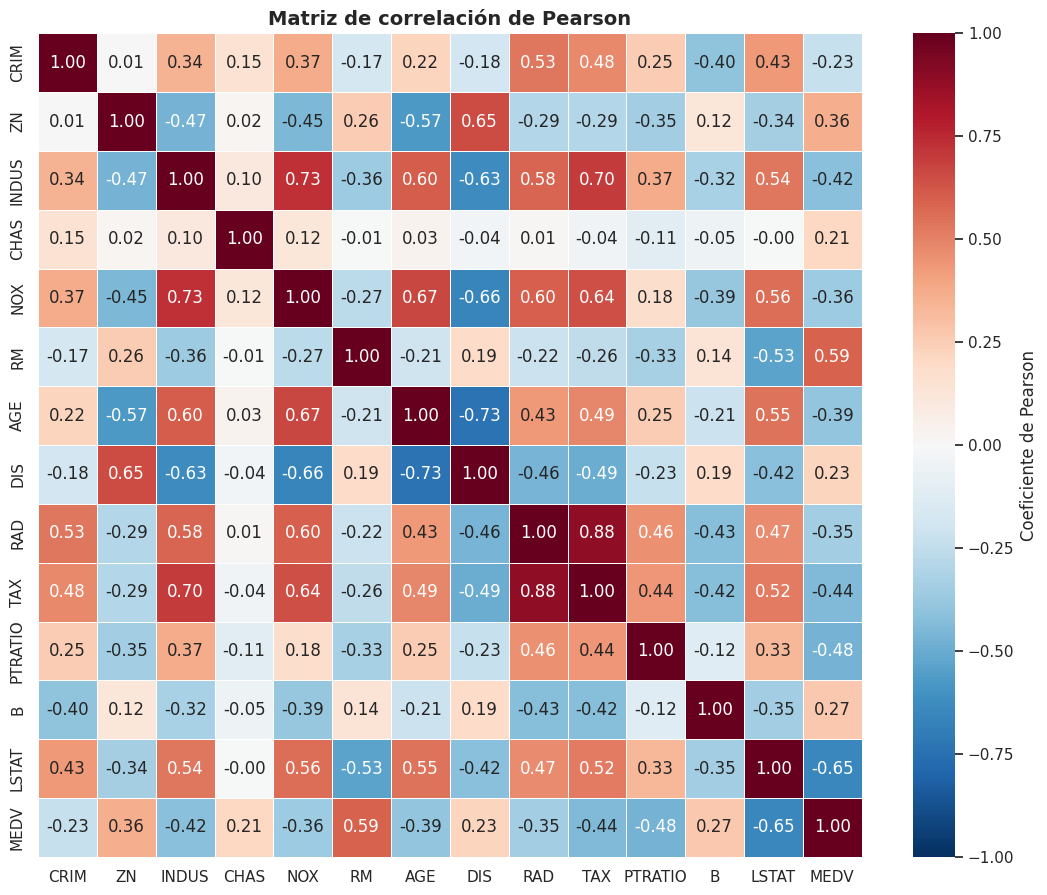

In [25]:
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de Pearson'})
plt.title('Matriz de correlación de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlación con el target (MEDV)

Las variables con mayor correlación lineal con MEDV son LSTAT (r = -0.65) y RM (r = 0.59). Esto indica que valores mayores de LSTAT tienden a asociarse con menores valores de MEDV, mientras que un mayor número promedio de habitaciones (RM) tiende a asociarse con mayores valores de MEDV.

También se observan correlaciones moderadas con PTRATIO (r = -0.48), TAX (r = -0.44) e INDUS (r = -0.42). Por otro lado, variables como CRIM (r = -0.23), DIS (r = 0.23) y CHAS (r = 0.21) presentan una correlación lineal más débil con el precio, aunque esto no implica necesariamente que no puedan aportar información predictiva.

## Colinealidad entre variables predictoras

Tomando como referencia |r| >= 0.7 para identificar relaciones lineales fuertes entre predictores, se destacan los siguientes pares:

RAD y TAX (r = 0.88): presentan la correlación positiva más alta entre las variables predictoras.
INDUS y NOX (r = 0.73): valores mayores de INDUS se encuentran asociados con mayores valores de NOX.
AGE y DIS (r = -0.73): valores mayores de AGE se encuentran asociados con menores valores de DIS.

Estas relaciones indican la posible presencia de multicolinealidad entre algunos predictores. Esto resulta relevante en regresión lineal, ya que una multicolinealidad elevada puede dificultar la interpretación de los coeficientes y hacer que sus estimaciones sean menos estables.

### Detección de valores atípicos mediante el método IQR

In [26]:
cols_iqr = [c for c in df.columns if c != 'CHAS']

Q1 = df[cols_iqr].quantile(0.25)
Q3 = df[cols_iqr].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = ((df[cols_iqr] < limite_inferior) | (df[cols_iqr] > limite_superior)).sum()
porcentaje_outliers = (outliers / df[cols_iqr].notna().sum() * 100).round(2)
print('Outliers por variable:')
print(outliers)
print()
print('Porcentaje de outliers por variable:')
print(porcentaje_outliers)

Outliers por variable:
CRIM       64
ZN         54
INDUS       0
NOX         0
RM         41
AGE         0
DIS        10
RAD         0
TAX         0
PTRATIO     0
B          86
LSTAT      11
MEDV       37
dtype: int64

Porcentaje de outliers por variable:
CRIM       12.21
ZN         10.34
INDUS       0.00
NOX         0.00
RM          7.78
AGE         0.00
DIS         1.89
RAD         0.00
TAX         0.00
PTRATIO     0.00
B          16.38
LSTAT       2.10
MEDV        6.95
dtype: float64


Se excluye CHAS de este análisis porque al ser una variable binaria, el método IQR no resulta adecuado para interpretar valores atípicos.

Las variables con mayor proporción de outliers son B, CRIM y ZN, lo cual es coherente con el sesgo marcado y la curtosis elevada observados previamente en el análisis descriptivo de estas variables.

Los valores atípicos detectados no se eliminan automáticamente, ya que no se encontraron indicios de que correspondan a errores de carga. En el caso de CRIM representan valores extremos pero posibles dentro de la distribución, mientras que en B y ZN también forman parte de la variabilidad propia del dataset.

---



##3.7 División del conjunto en entrenamiento y prueba

Antes de imputar y escalar, se divide el dataset en entrenamiento y prueba para evitar data leakage. La imputación y el escalado se ajustarán únicamente con los datos de entrenamiento.

In [27]:
# Split ANTES de imputar y de estandarizar (evita data leakage en ambos pasos).
# nulos: se imputan recien despues de dividir el dataset
X = df[col_numericas + [col_categorica]]
Y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_STATE)


print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')
print(f'Nulos en X_train: {X_train.isnull().sum().sum()} | Nulos en X_test: {X_test.isnull().sum().sum()}')
print(f'Nulos en y_train: {y_train.isnull().sum()} | Nulos en y_test: {y_test.isnull().sum()}')

Train: 425 filas | Test: 107 filas
Nulos en X_train: 67 | Nulos en X_test: 23
Nulos en y_train: 0 | Nulos en y_test: 0


###Instalacion de dependencia para utilizar Catboost

In [28]:
!pip install catboost

In [29]:
from catboost import CatBoostClassifier

cat_features = []
drop_cols = ["CHAS"]
#Las filas donde CHAS es conocido sirven para entrenar
train_chas = X_train[X_train["CHAS"].notna()].copy()

# Las filas donde CHAS es desconocido queremos predecirlas
test_chas = X_train[X_train["CHAS"].isna()].copy()


# Variables predictoras de las filas donde CHAS es conocido
X_train_chas = train_chas.drop(columns = drop_cols, errors = "ignore") #las variables con las que CatBoost aprende.

#CHAS conocido
Y_train_chas = train_chas["CHAS"].astype(int) #lo que CatBoost tiene que aprender a predecir.

#Datos donde queremos predecir CHAS
X_test_chas = test_chas.drop(columns=drop_cols, errors="ignore") #las filas con CHAS faltante, pero conservando el resto de la información para poder predecirlo.

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    cat_features=cat_features,
    verbose=False,
    random_seed=RANDOM_STATE)


cat_model.fit(X_train_chas, Y_train_chas)


pred_chas_train = cat_model.predict(X_test_chas)



imputed_chas = X_train.copy()

imputed_chas.loc[test_chas.index, "CHAS"] = pred_chas_train

print("Faltantes en CHAS tras imputación:",imputed_chas["CHAS"].isna().sum())

Faltantes en CHAS tras imputación: 0


In [30]:
# Copia de X_test para conservar el original
imputed_chas_test = X_test.copy()

# Filas de test donde CHAS es faltante
test_chas_test = imputed_chas_test[imputed_chas_test["CHAS"].isna()].copy()

# Variables predictoras
X_test_chas_test = test_chas_test.drop(columns=["CHAS"], errors="ignore")

# Predicción con el mismo modelo entrenado en train
pred_chas_test = cat_model.predict(X_test_chas_test)

# Imputación
imputed_chas_test.loc[test_chas_test.index, "CHAS"] = pred_chas_test

# Verificación
print("Faltantes en CHAS de test tras imputación:",imputed_chas_test["CHAS"].isna().sum())

Faltantes en CHAS de test tras imputación: 0


### Imputación de CHAS con CatBoost

En la primera celda se entrena un modelo CatBoost utilizando las filas de entrenamiento donde CHAS tiene un valor conocido. Luego, el modelo predice los valores faltantes de CHAS dentro del conjunto de entrenamiento.

En la segunda celda se reutiliza el mismo modelo ya entrenado para predecir los valores faltantes de CHAS en el conjunto de prueba, evitando volver a entrenarlo y prevenir data leakage.

In [31]:
imputed_chas_test["CHAS"].isna().value_counts()

,count
CHAS,
False,107


In [32]:
imputed_chas["CHAS"].isna().value_counts()

,count
CHAS,
False,425


In [33]:
from sklearn.preprocessing import RobustScaler

# Tomamos únicamente las variables predictoras numéricas.
# MEDV queda aparte porque es la variable target y sus faltantes ya fueron eliminados previamente.

train_num = imputed_chas[col_numericas].copy()
test_num = imputed_chas_test[col_numericas].copy()


# Escalar (RobustScaler) fit solo con train
scaler_temp = RobustScaler()

train_scaled = pd.DataFrame(scaler_temp.fit_transform(train_num),columns=col_numericas, index=train_num.index)

test_scaled = pd.DataFrame(scaler_temp.transform(test_num),columns=col_numericas, index=test_num.index)

In [34]:
from sklearn.impute import KNNImputer

# Imputar con KNN - fit solo en train, transform en train y test
imputer = KNNImputer(n_neighbors = 5)

train_imp_scaled = pd.DataFrame(imputer.fit_transform(train_scaled),columns = col_numericas, index = train_num.index)

test_imp_scaled = pd.DataFrame(imputer.transform(test_scaled),columns = col_numericas, index = test_num.index)


# Volver a la escala original (inverse_transform)
train_imputado = pd.DataFrame(scaler_temp.inverse_transform(train_imp_scaled),columns=col_numericas, index=train_num.index)
test_imputado = pd.DataFrame(scaler_temp.inverse_transform(test_imp_scaled),columns=col_numericas, index=test_num.index)


imputed_chas[col_numericas] = train_imputado[col_numericas]
imputed_chas_test[col_numericas] = test_imputado[col_numericas]

In [35]:
#Control sobre posible existencia de valores nulos en train
imputed_chas.isna().value_counts()

,,,,,,,,,,,,,count
CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,CHAS,
False,False,False,False,False,False,False,False,False,False,False,False,False,425


In [36]:
#Control sobre posible existencia de valores nulos en test
imputed_chas_test.isna().value_counts()

,,,,,,,,,,,,,count
CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,CHAS,
False,False,False,False,False,False,False,False,False,False,False,False,False,107


In [37]:
#Reemplazamos directamente en la variable X_train y X_test los valores ya imputados
X_train = imputed_chas
X_test = imputed_chas_test

In [38]:
#Verificacion de nulos
print('Nulos restantes - X_train:', X_train.isnull().sum().sum(), '| X_test:', X_test.isnull().sum().sum())
print('Nulos restantes - y_train:', y_train.isnull().sum(), '| y_test:', y_test.isnull().sum())

Nulos restantes - X_train: 0 | X_test: 0
Nulos restantes - y_train: 0 | y_test: 0


###Prevención de data leakage:
Fit en train → transform en test: la información fluye en un solo sentido (train → test). Test nunca influye en nada que se use para procesar train (no leakage).

Fit en train + test juntos (imputar/escalar antes del split): la información fluye en ambos sentidos. Un valor de test puede terminar afectando cómo se procesa una fila de train, y viceversa (leakage).

In [39]:
# Transformación logarítmica de CRIM y DIS (sesgo positivo). No elimina outliers solo comprime su escala.
for col in ['CRIM', 'DIS']:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

# ZN: 73.5% de valores en 0 (zero-inflada), log1p mejora poco -> se deja sin transformar
# MEDV: es el target, se evaluará en la sección de modelado (punto 4), no acá

##3.8 Estandarización de variables numéricas

Se utilizó StandardScaler (no RobustScaler) para este paso, ya que los modelos que se entrenan a continuación (regresión lineal, Ridge y Lasso) se benefician de trabajar con variables estandarizadas, con media 0 y desvío estándar 1.

In [40]:
scaler = StandardScaler()

# Fit sobre sobre train, transform sobre train y test
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean', 'std']]  # verificación: media ~0, std ~1 en train

,mean,std
CRIM,2.507798e-17,1.001179
ZN,-1.044916e-17,1.001179
INDUS,-1.671865e-17,1.001179
NOX,-3.636307e-16,1.001179
RM,5.266376e-16,1.001179
AGE,8.359326e-18,1.001179
DIS,-2.048035e-16,1.001179
RAD,-5.224579e-17,1.001179
TAX,5.642545e-17,1.001179
PTRATIO,7.063631e-16,1.001179


##Consigna 4

##Implementar la solución del problema de regresión con regresión lineal múltiple.

Se decidió no eliminar los outliers de CRIM y B por corresponder a una subpoblación real del dataset. Sin embargo, dado que los modelos evaluados (LinearRegression, Ridge, Lasso, Elastic Net) minimizan el error cuadrático, son sensibles a la influencia desproporcionada de estos valores extremos sobre el ajuste. Esto se mitigó parcialmente aplicando log1p a CRIM y DIS, reduciendo la asimetría de ambas variables sin eliminar los valores extremos.

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

###4.1 Método LinearRegression

In [42]:
# Entrenamiento
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

# Predicciones en ambos conjuntos
pred_train = modelo_lr.predict(X_train_scaled)
pred_test = modelo_lr.predict(X_test_scaled)

print('Metricas de train (regresion lineal)')
print('R²:', round(metrics.r2_score(y_train, pred_train), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train), 4))

print('Metricas de test (regresion lineal)')
print('R²:', round(metrics.r2_score(y_test, pred_test), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test), 4))

Metricas de train (regresion lineal)
R²: 0.6188
RMSE: 5.9619
MAE: 3.9303
Metricas de test (regresion lineal)
R²: 0.5893
RMSE: 5.5178
MAE: 3.6249


- R² de train ≈ R² de test → el modelo presenta un comportamiento similar en datos de entrenamiento y prueba.
- R² de train >> R² de test → podría indicar overfitting.
- R² bajos tanto en train como en test → podría indicar underfitting, aunque esto depende del problema y debe analizarse junto con otras métricas.

Con LinearRegression se obtuvo un fitting moderado. No se observan señales claras de overfitting, ya que los valores de R² de train (0.62) y test (0.59) son similares.

El modelo explica aproximadamente el 62% de la variabilidad de MEDV en entrenamiento y el 59% en prueba.

El MAE representa el error absoluto promedio en dolares. En test se obtuvo un MAE aproximado de 3.62, lo que equivale a un error promedio de aproximadamente 3.62 miles de dólares.

El RMSE penaliza en mayor medida los errores grandes. RMSE es bastante más grande que MAE, significa que hay algunas predicciones con error bastante grande que están inflando el RMSE más de lo que inflarían el MAE.

In [43]:
# Coeficientes aprendidos por la regresión lineal para cada variable predictora.
#El signo positivo o negativo indica la relacion que existe con MEDV y el valor refleja el peso en el modelo.
print(modelo_lr.coef_)

[ 0.81403786  0.85656883 -0.19186483 -0.23068388  3.31954751 -1.79296193
 -2.75057722  0.89060644 -2.23196419 -1.63341634  0.73132488 -3.11818269
  1.54098176]


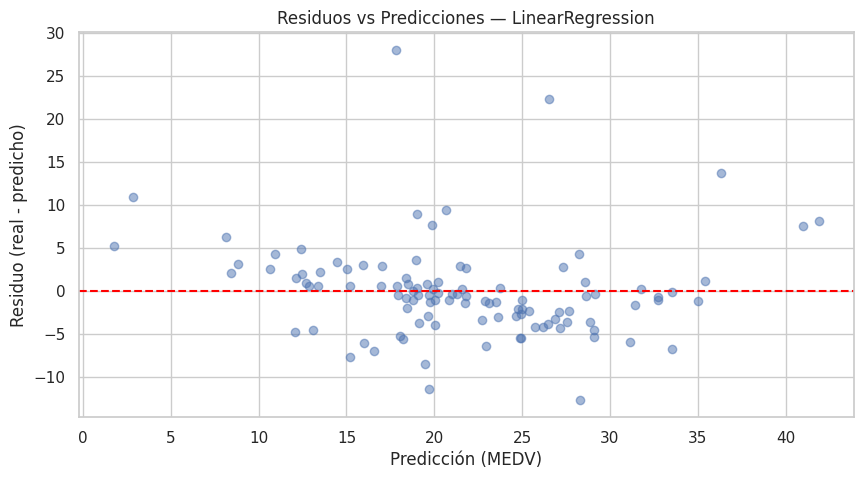

In [44]:
#Grafico de residuos
residuos = y_test - pred_test

plt.figure(figsize=(10, 5))
plt.scatter(pred_test, residuos, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicción (MEDV)')
plt.ylabel('Residuo (real - predicho)')
plt.title('Residuos vs Predicciones — LinearRegression')
plt.show()

Los residuos se encuentran dispersos alrededor de cero, aunque se puede observar una mayor concentracion de valores negativos en algunas partes del grafico. Los residuos por debajo de la linea del cero indican una sobreestimacion del modelo, mientras que los que se encuentran sobre cero presentan una subestimacion. Junto a esto, observamos algunos valores muy elevados, lo que indica que existen casos donde el modelo presenta errores considerablemente mas grandes

##4.2 Gradiente descendiente

In [45]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):

    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1


        # Inicializar pesos aleatorios
        W = W - (lr * gradient)

            # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W

In [46]:
np.random.seed(RANDOM_STATE)  # reproducibilidad de la inicialización de W

X_train_np = X_train_scaled.to_numpy()
X_test_np = X_test_scaled.to_numpy()
y_train_np = y_train.to_numpy().reshape(-1, 1)
y_test_np = y_test.to_numpy().reshape(-1, 1)

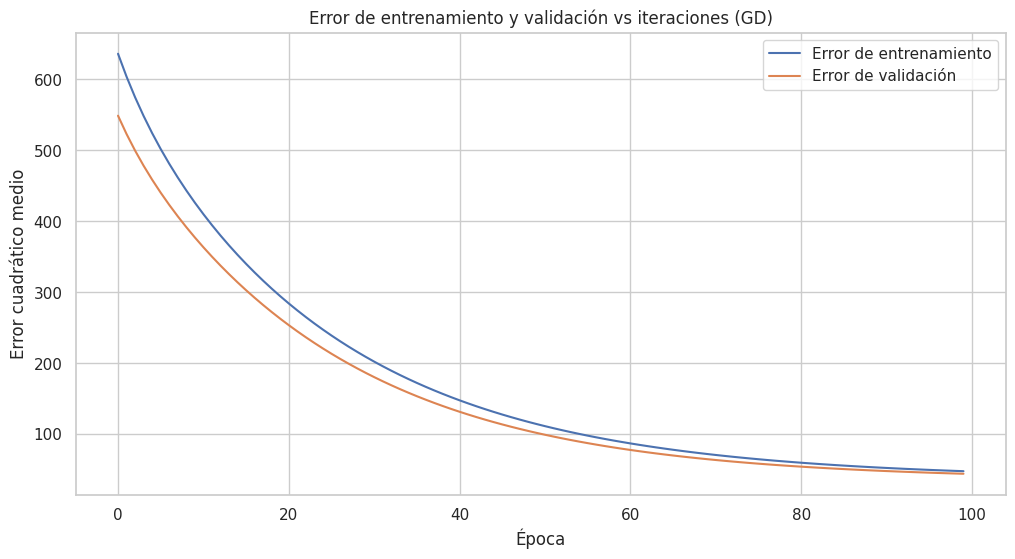

In [47]:
# Se usan los hiperparámetros por defecto de la función, sin ajustar nada todavía
# se hace en el punto 5.
np.random.seed(RANDOM_STATE)
W_gd = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.01, epochs=100)

In [48]:
print(W_gd)
# Estos son los pesos que apendió el modelo, el primero es el bias (el precio base cuando todas
# las variables estan en su promedio porque estan estandarizadas)
# los otros son los coeficientes de cada variable

[[ 2.00720225e+01]
 [-2.07507453e-02]
 [ 8.45011342e-01]
 [ 3.90235662e-01]
 [-3.77560685e-01]
 [ 3.11211335e+00]
 [ 1.66726176e-02]
 [-2.68900182e-01]
 [-2.62027036e-01]
 [-4.51335281e-01]
 [-1.90935115e+00]
 [ 4.58710564e-01]
 [-2.75152797e+00]
 [ 1.33801173e+00]]


In [49]:
X_train_b = np.hstack([np.ones((X_train_np.shape[0], 1)), X_train_np])
X_test_b = np.hstack([np.ones((X_test_np.shape[0], 1)), X_test_np])
pred_train_gd = (X_train_b @ W_gd).ravel()
pred_test_gd = (X_test_b @ W_gd).ravel()

print('Métricas de train (Gradient Descent)')
print('R²:', round(metrics.r2_score(y_train, pred_train_gd), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train_gd)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train_gd), 4))

print('Métricas de test (Gradient Descent)')
print('R²:', round(metrics.r2_score(y_test, pred_test_gd), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test_gd)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test_gd), 4))

Métricas de train (Gradient Descent)
R²: 0.4878
RMSE: 6.9112
MAE: 4.4177
Métricas de test (Gradient Descent)
R²: 0.4034
RMSE: 6.6505
MAE: 4.1323


In [50]:
comparacion = pd.DataFrame({
    'Variable': ['bias'] + col_numericas + [col_categorica],
    'GD': W_gd.ravel().round(3),
    'LinearRegression': [round(modelo_lr.intercept_, 3)] + list(modelo_lr.coef_.round(3))
})

comparacion['Diferencia'] = (comparacion['GD'] - comparacion['LinearRegression']).round(3)

comparacion

,Variable,GD,LinearRegression,Diferencia
0,bias,20.072,23.065,-2.993
1,CRIM,-0.021,0.814,-0.835
2,ZN,0.845,0.857,-0.012
3,INDUS,0.390,-0.192,0.582
4,NOX,-0.378,-0.231,-0.147
5,RM,3.112,3.320,-0.208
6,AGE,0.017,-1.793,1.810
7,DIS,-0.269,-2.751,2.482
8,RAD,-0.262,0.891,-1.153
9,TAX,-0.451,-2.232,1.781


Con los hiperparámetros utilizados (lr=0.01, epochs=100), el gradiente descendente no llega a converger completamente.

El R² de test da aproximadamente 0.40, peor que LinearRegression (aproximadamente 0.59), y los valores de RMSE y MAE también son mayores.

Los pesos obtenidos difieren de los de LinearRegression.

Esto sugiere que lr=0.01 puede ser demasiado chico y/o epochs=100 insuficiente para esa tasa de aprendizaje.

En el punto 5 se explora un barrido de hiperparámetros.

###4.3 Métodos de regularización (Ridge, Lasso, Elastic Net)

Probamos los tres métodos de regularización, con un alpha elegido a mano.

Usamos X_train_scaled (x train escalado) porque estos métodos penalizan la magnitud de los coeficientes y eso es comparable entre variables solo si están en la misma escala.

In [51]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Hiperparámetros iniciales
lasso = Lasso(alpha=0.01)
ridge = Ridge(alpha=0.1)
elasticnet = ElasticNet(alpha=0.01, l1_ratio=0.5)
#Ajustes de cada modelo
lasso.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
elasticnet.fit(X_train_scaled, y_train)

#Resultados de train y test de cada metodo
print('Ridge score train:', ridge.score(X_train_scaled, y_train))
print('Ridge score test:', ridge.score(X_test_scaled, y_test))

print('Lasso score train:', lasso.score(X_train_scaled, y_train))
print('Lasso score test:', lasso.score(X_test_scaled, y_test))

print('ElasticNet score train:', elasticnet.score(X_train_scaled, y_train))
print('ElasticNet score test:', elasticnet.score(X_test_scaled, y_test))

Ridge score train: 0.6188087672434437
Ridge score test: 0.5892173736848543
Lasso score train: 0.6187649319712418
Lasso score test: 0.5869330211262209
ElasticNet score train: 0.6187336608765113
ElasticNet score test: 0.5862102441946933


In [52]:
comparacion_coefs = pd.DataFrame({
    'Variable': col_numericas + [col_categorica],
    'Ridge': ridge.coef_.round(3),
    'Lasso': lasso.coef_.round(3),
    'ElasticNet': elasticnet.coef_.round(3),
    'LinearRegression': modelo_lr.coef_.round(3)})
comparacion_coefs

,Variable,Ridge,Lasso,ElasticNet,LinearRegression
0,CRIM,0.813,0.766,0.765,0.814
1,ZN,0.856,0.839,0.832,0.857
2,INDUS,-0.193,-0.194,-0.211,-0.192
3,NOX,-0.230,-0.193,-0.204,-0.231
4,RM,3.319,3.319,3.309,3.320
5,AGE,-1.791,-1.764,-1.742,-1.793
6,DIS,-2.747,-2.677,-2.650,-2.751
7,RAD,0.888,0.816,0.795,0.891
8,TAX,-2.227,-2.135,-2.092,-2.232
9,PTRATIO,-1.633,-1.620,-1.624,-1.633


Con estos alphas (chicos), los coeficientes de los tres modelos regularizados son muy parecidos a los de LinearRegression, la penalización es leve.

Lasso no descartó ninguna variable (ningún coeficiente en 0), lo cual es esperable con un alpha tan chico como 0.01.

###4.4 Obtener las métricas adecuadas tanto para entrenamiento como para prueba.

Métricas elegidas: R², RMSE y MAE.

R² indica qué proporción de la variabilidad de MEDV explica el modelo, es más directa para responder si es buen fitting.

RMSE penaliza más los errores grandes (por el cuadrado)

MAE es más robusto a outliers.

Comparar ambas permite detectar si hay pocas predicciones malas dominando el error (si RMSE >> MAE, es señal de eso).

Se descartan MSE y MAPE:

MSE da la misma información que RMSE pero en unidades al cuadrado, menos interpretable.

MAPE pondera los errores en términos porcentuales. Un mismo error en dólares pesa más porcentualmente en las casas baratas que en las caras.

In [53]:
def calcular_metricas(y_true, y_pred):
    r2 = metrics.r2_score(y_true, y_pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_true, y_pred))
    mae = metrics.mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

# Predicciones ya calculadas
modelos_pred = {
    'LinearRegression': (pred_train, pred_test),
    'Gradient Descent': (pred_train_gd, pred_test_gd),
    'Ridge': (ridge.predict(X_train_scaled), ridge.predict(X_test_scaled)),
    'Lasso': (lasso.predict(X_train_scaled), lasso.predict(X_test_scaled)),
    'ElasticNet': (elasticnet.predict(X_train_scaled), elasticnet.predict(X_test_scaled)),
}

#pt: predicciones de train
#pte: predicciones de test

filas = []
for nombre, (pt, pte) in modelos_pred.items():
    r2_tr, rmse_tr, mae_tr = calcular_metricas(y_train, pt)
    r2_te, rmse_te, mae_te = calcular_metricas(y_test, pte)
    filas.append({
        'Modelo': nombre,
        'R² train': round(r2_tr, 4), 'R² test': round(r2_te, 4),
        'RMSE train': round(rmse_tr, 4), 'RMSE test': round(rmse_te, 4),
        'MAE train': round(mae_tr, 4), 'MAE test': round(mae_te, 4),
    })

df_metricas = pd.DataFrame(filas)
df_metricas

,Modelo,R² train,R² test,RMSE train,RMSE test,MAE train,MAE test
0,LinearRegression,0.6188,0.5893,5.9619,5.5178,3.9303,3.6249
1,Gradient Descent,0.4878,0.4034,6.9112,6.6505,4.4177,4.1323
2,Ridge,0.6188,0.5892,5.9619,5.5184,3.9303,3.6247
3,Lasso,0.6188,0.5869,5.9623,5.5338,3.9328,3.6233
4,ElasticNet,0.6187,0.5862,5.9625,5.5386,3.9322,3.6210


La métrica de train sola no dice si el modelo generaliza

Un modelo puede ajustar perfecto los datos que ya vio y fallar con datos nuevos (overfitting).

Train ≈ Test: el modelo generaliza bien.

Train >> Test: señal de overfitting, el modelo memorizó el ruido de entrenamiento.

Ambas malas: underfitting, el modelo es demasiado simple para el problema.

En este caso, la similitud entre train y test en LinearRegression, Ridge, Lasso y ElasticNet confirma que no hay overfitting.

Gradient Descent presenta un rendimiento inferior, pero corresponde a la versión todavía sin optimizar (lr=0.01, epochs=100)

###¿Por qué para ambos conjuntos?

Se calculan las métricas en ambos conjuntos para comparar el rendimiento del modelo con los datos que utilizó para entrenarse y con datos que no vio durante el entrenamiento.


###¿Creen que han conseguido un buen fitting?

Como las metricas de train y test son bastante proximas entre si entre los diferentes modelos, podemos decir que tienen un comportamiento similar entre los conjuntos sin indicar de manera clara overfitting. Sin embargo, como el R cuadrado se encuentra aproximadamente en 0.59 en casi todos los modelos, consideramos que el fitting todavia puede tener margen de mejora.

##Consigna 5
##Optimizacion de la seleccion de hiperparametros

## 5.1 Optimizacion de gradiente descendente

En la consigna 4 usamos los valores por defecto (lr=0.01, epochs=100) que no llegaban a converger (R² test≈0.40). Acá probamos manualmente otras combinaciones para ver el efecto de cada hiperparámetro.

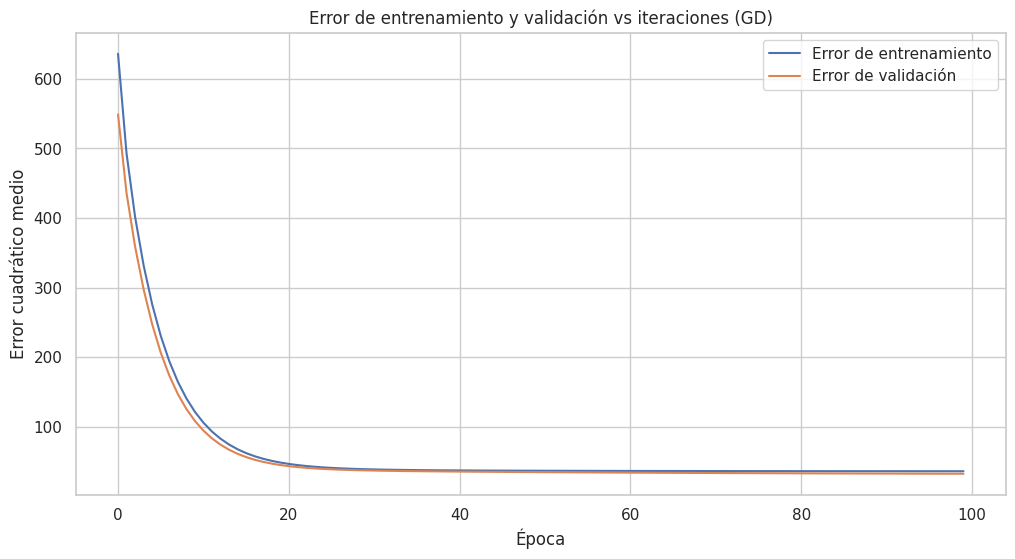

In [54]:
# Intento 1: subimos lr
np.random.seed(RANDOM_STATE)
W_prueba1 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.05, epochs=100)
pred_test_prueba1 = (X_test_b @ W_prueba1).ravel()

In [55]:
print('lr=0.05, epochs=100 | R² test:', round(metrics.r2_score(y_test, pred_test_prueba1), 4))

lr=0.05, epochs=100 | R² test: 0.5675


En este primer intento cambiando el hiperparametro lr a 0.05, donde podemos observar que hubo una mejoria notoria en el modelo, tanto con el R², obteniendo un valor aproximado de 0.57 y a su vez, las curvas se estabilizan mas rapido que con lr = 0.01.

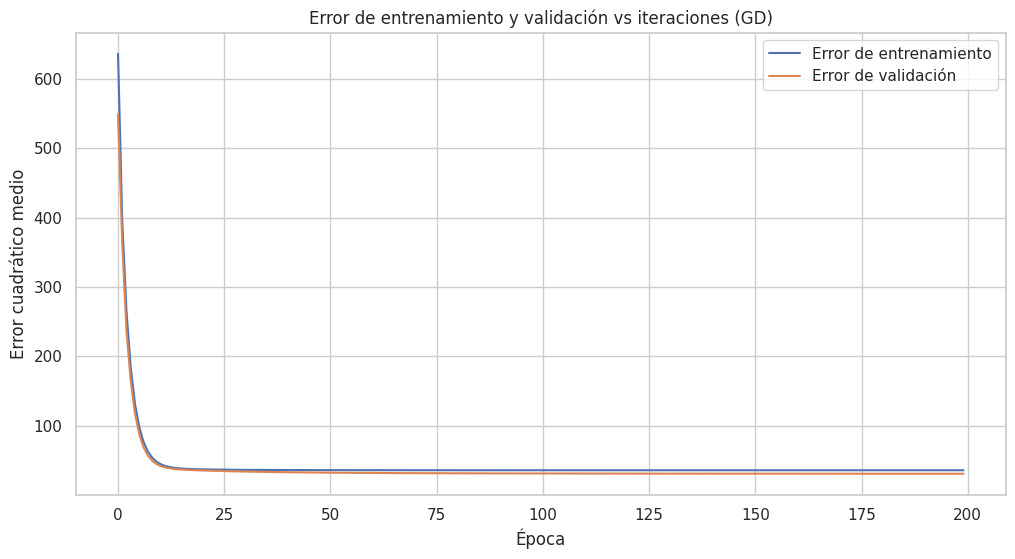

In [56]:
# Intento 2: lr más alto, más epochs
np.random.seed(RANDOM_STATE)
W_prueba2 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.1, epochs=200)
pred_test_prueba2 = (X_test_b @ W_prueba2).ravel()

In [57]:
print('lr=0.1, epochs=200 | R² test:', round(metrics.r2_score(y_test, pred_test_prueba2), 4))

lr=0.1, epochs=200 | R² test: 0.5885


En este segundo intento decidimos aumentar el lr a 0.1 y a su vez aumentamos los epoch a 200. En este caso se obtuvo un R² aproximado de 0.59, una mejoria sobre el caso base y el primer intento. Ademas las curvas descienden mas rapido que en el primer intento y se estabilizan mas rapido.

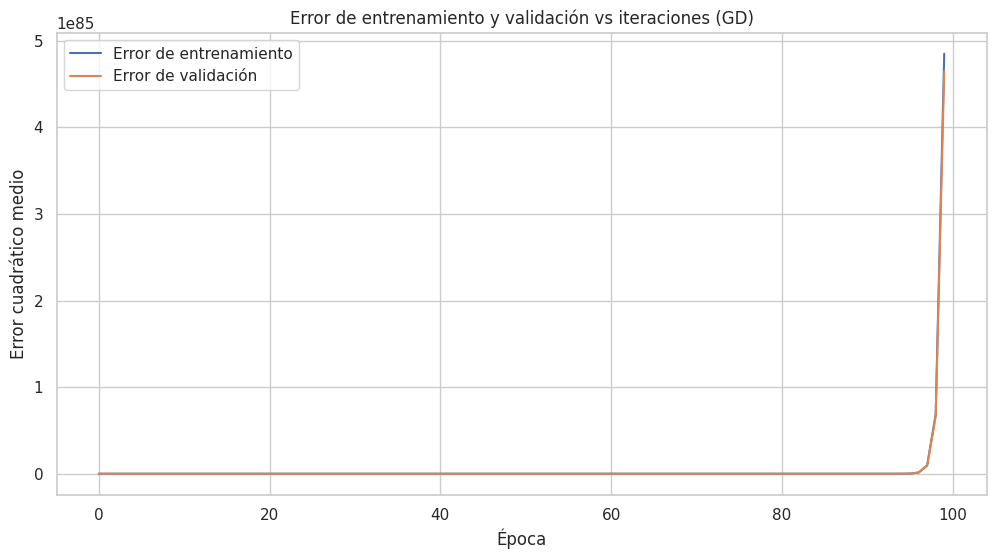

In [58]:
# Intento 3: lr demasiado alto
np.random.seed(RANDOM_STATE)
W_prueba3 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.3, epochs=100)
pred_test_prueba3 = (X_test_b @ W_prueba3).ravel()

In [59]:
print('lr=0.3, epochs=100 | R² test:', metrics.r2_score(y_test, pred_test_prueba3))

lr=0.3, epochs=100 | R² test: -4.42431961836209e+84


En este tercer intento, se elevó aún más el learning rate (lr=0.3) y se mantuvieron las épocas (epochs=100). Se observa que el error crece de forma descontrolada y el R² toma un valor extremadamente negativo. Esto indica que el learning rate es demasiado alto, logrando que gradiente descendiente se aleje de la solucion optima.

En estos 3 intentos pudimos observar lo siguiente:
A medida que aumenta el learning rate, el modelo converge mas, pero hasta cierto punto.

lr = 0.05 obtuvo un R² test aproximado de 0.57
lr = 0.1 obtuvo un R² test aproximado de 0.59, alcanzando a la Regresion Lineal
lr = 0.3 al aumentar tanto hace que el modelo diverja en vez de mejorar.

In [60]:
#Comparamos el mejor resultado que obtuvimos en gradient descent(intento 2) con la regresion lineal
comparacion = pd.DataFrame({
    'Variable': ['bias'] + col_numericas + [col_categorica],
    'GD': W_prueba2.ravel().round(3),
    'LinearRegression': [round(modelo_lr.intercept_, 3)] + list(modelo_lr.coef_.round(3))
})

comparacion['Diferencia'] = (comparacion['GD'] - comparacion['LinearRegression']).round(3)

comparacion

,Variable,GD,LinearRegression,Diferencia
0,bias,23.065,23.065,0.000
1,CRIM,0.826,0.814,0.012
2,ZN,0.850,0.857,-0.007
3,INDUS,-0.209,-0.192,-0.017
4,NOX,-0.234,-0.231,-0.003
5,RM,3.318,3.320,-0.002
6,AGE,-1.791,-1.793,0.002
7,DIS,-2.752,-2.751,-0.001
8,RAD,0.843,0.891,-0.048
9,TAX,-2.183,-2.232,0.049


Con lr = 0.1 y epochs = 200, las metricas de los dos modelos son muy similares con R² aproximado de 0.5885 en GD y 0.5893 en Regresion Lineal, logrando diferencias muy bajas entre modelos.

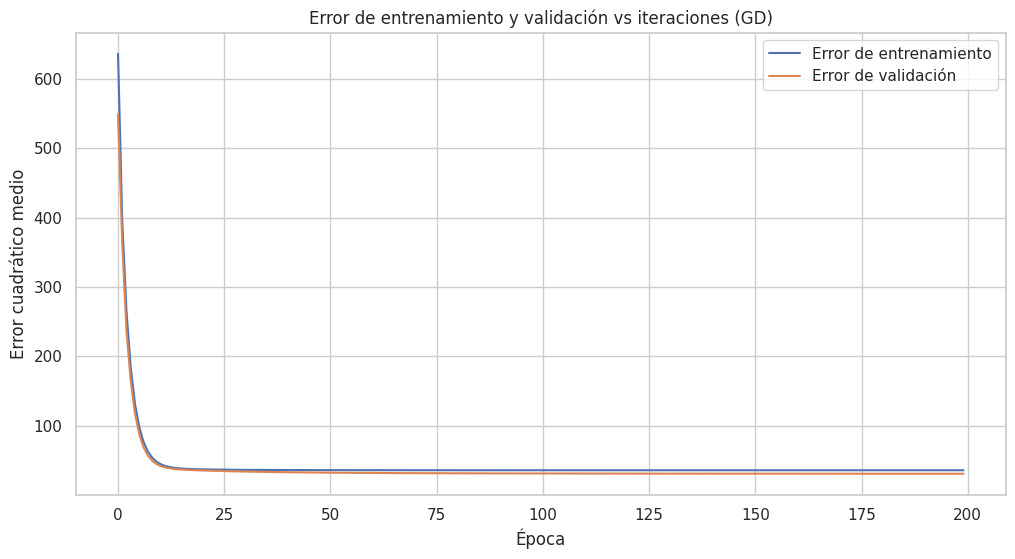

In [61]:
#Nos quedamos con este modelo

np.random.seed(RANDOM_STATE)

W_prueba2 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.1, epochs=200)

pred_train_prueba2 = (X_train_b @ W_prueba2).ravel()
pred_test_prueba2 = (X_test_b @ W_prueba2).ravel()

###5.2 Variar los hiperparámetros de Lasso y Ridge

In [62]:
# Importamos los modelos con validación cruzada
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV

# Crear modelos usando validacion cruzada de 5 folds
lassoCV = LassoCV(cv=5)  # alpha controla la fuerza de la regularización L1 (Lasso)
ridgeCV = RidgeCV(cv=5)  # alpha controla la fuerza de la regularización L2 (Ridge)
elasticnetCV = ElasticNetCV(cv=5)

# Ajustar modelos a los datos de entrenamiento
lassoCV.fit(X_train_scaled, y_train)
ridgeCV.fit(X_train_scaled, y_train)
elasticnetCV.fit(X_train_scaled, y_train)

#Mostrar alphas
print(f"Alpha de Lasso: ", lassoCV.alpha_)
print(f"Alpha de Ridge: ", ridgeCV.alpha_)
print(f"Alpha de ElasticNet", elasticnetCV.alpha_ )

Alpha de Lasso:  0.06530357837891408
Alpha de Ridge:  10.0
Alpha de ElasticNet 0.0859307878090344


Se utilizó validación cruzada de 5 folds para seleccionar automáticamente los valores de alpha de Lasso, Ridge y ElasticNet utilizando únicamente los datos de entrenamiento.

El valor de alpha de cada modelo corresponde al error cuadratico medio de validacion donde dio un valor menor

###Consigna 6

### Comparacion de modelos

Se comparan los 5 modelos usando las métricas R², RMSE, MAE, calculadas sobre test.

Se usan las versiones finales de cada modelo

In [63]:
# Predicciones de cada modelo despues del ajuste de hiperparámetros
modelos_finales = {
    'LinearRegression': (pred_train, pred_test),
    'Gradient Descent': (pred_train_prueba2, pred_test_prueba2),
    'Ridge': (ridgeCV.predict(X_train_scaled), ridgeCV.predict(X_test_scaled)),
    'Lasso': (lassoCV.predict(X_train_scaled), lassoCV.predict(X_test_scaled)),
    'ElasticNet': (elasticnetCV.predict(X_train_scaled), elasticnetCV.predict(X_test_scaled)),
}

filas = []
for nombre, (pt, pte) in modelos_finales.items():
    r2_tr, rmse_tr, mae_tr = calcular_metricas(y_train, pt)
    r2_te, rmse_te, mae_te = calcular_metricas(y_test, pte)
    filas.append({
        'Modelo': nombre,
        'R² train': round(r2_tr, 4), 'R² test': round(r2_te, 4),
        'RMSE train': round(rmse_tr, 4), 'RMSE test': round(rmse_te, 4),
        'MAE train': round(mae_tr, 4), 'MAE test': round(mae_te, 4),
    })

df_comparacion_final = pd.DataFrame(filas).sort_values('RMSE test')
df_comparacion_final

,Modelo,R² train,R² test,RMSE train,RMSE test,MAE train,MAE test
0,LinearRegression,0.6188,0.5893,5.9619,5.5178,3.9303,3.6249
1,Gradient Descent,0.6188,0.5885,5.9620,5.5234,3.9303,3.6265
2,Ridge,0.6182,0.5810,5.9665,5.5735,3.9353,3.6148
3,Lasso,0.6170,0.5709,5.9764,5.6398,3.9549,3.6612
4,ElasticNet,0.6151,0.5647,5.9911,5.6805,3.9690,3.6644


Métrica para comparar: RMSE de test, porque permite ver qué modelo tiene menor error y penaliza más los errores grandes.

El mejor modelo es Regresion Lineal con un RMSE test aproximado de 5.52 y con un R² superior al de resto con un valor aproximado de 0.59.

ElasticNet obtuvo el resultado más bajo, con un alpha aproximado de 0.086, un RMSE de test de 5.68 y un R² aproximado de 0.56.

### Consigna 7


## Conclusión

Sobre el preprocesamiento:

El dataset presentó valores faltantes, por lo que se eliminaron las filas donde faltaba la variable target MEDV y aquellas con más del 50% de datos faltantes. Para el resto de los valores se utilizó CatBoost para imputar CHAS y KNN para las variables numéricas.

Se aplicó una transformación logarítmica sobre CRIM y DIS debido a su sesgo positivo y posteriormente se estandarizaron las variables utilizando StandardScaler. El ajuste del escalado y de la imputación se realizó sobre train para evitar data leakage.

Sobre los modelos:

LinearRegression obtuvo el mejor resultado final, con un RMSE de test aproximado de 5.52 y un R² de test aproximado de 0.59.

Gradient Descent inicialmente obtuvo resultados inferiores, pero al modificar sus hiperparámetros (lr=0.1, epochs=200) logró resultados muy similares a LinearRegression, tanto en sus métricas como en los coeficientes obtenidos.

Para Ridge, Lasso y ElasticNet se utilizó validación cruzada de 5 folds para elegir el valor de alpha. Los valores obtenidos fueron aproximadamente 10 para Ridge, 0.065 para Lasso y 0.086 para ElasticNet. Ninguno de estos modelos logró mejorar el resultado de LinearRegression.

Se consiguió un fitting moderado.

Las métricas de train y test son bastante próximas entre sí en los diferentes modelos, por lo que no se observan señales claras de overfitting. Sin embargo, con un R² de test cercano a 0.59, todavía existe una parte de la variabilidad de MEDV que los modelos no logran explicar, por lo que existe margen de mejora.